
**Quantum Reservoir Simulation for Geothermal & CO₂ Sequestration**


1) Subsurface reservoir modeling

Used for: geothermal energy, CO₂ sequestration

Challenges: complex physics, high-dimensional PDEs, uncertainty in geology

Impact: climate mitigation, renewable energy

Tie to SDGs: SDG 7 , SDG 13, SDG 9, SDG 15



2) Classical challenges:

 Large nonlinear PDE systems
 Monte-Carlo uncertainty simulations
 Parameter inversion



3) Where Quantum can help in:

Linear system solvers : (HHL-type algorithms), For solving discretized PDEs.

Quantum Monte Carlo for faster uncertainty estimation.

Optimization for injection strategy / well placement.



4) Roadmap:

Phase 1:- Problem formulation

Phase 2:- Proof of concept

Example: synthetic reservoir dataset, hybrid optimization, small-scale quantum simulation

Phase 3:- hardware testing

In [13]:
!pip install pennylane pennylane-lightning pennylane-qiskit --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 46.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 84.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 81.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 14.8 MB/s eta 0:00:0

In [3]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import itertools

In [2]:
print("""
Quantum Reservoir Simulation for Geothermal & CO₂ Sequestration

Goal:
Use hybrid quantum–classical optimization to improve planning of CO₂ injection 
and geothermal reservoirs by accelerating uncertainty analysis and well placement decisions.

Alignment:
SDG 7 – Affordable and Clean Energy
SDG 9 – Industry, Innovation, Infrastructure
SDG 13 – Climate Action
SDG 15 - Land & Subsurface ecosystems
""")


Quantum Reservoir Simulation for Geothermal & CO₂ Sequestration

Goal:
Use hybrid quantum–classical optimization to improve planning of CO₂ injection 
and geothermal reservoirs by accelerating uncertainty analysis and well placement decisions.

Alignment:
SDG 7 – Affordable and Clean Energy
SDG 9 – Industry, Innovation, Infrastructure
SDG 13 – Climate Action
SDG 15 - Land & Subsurface ecosystems



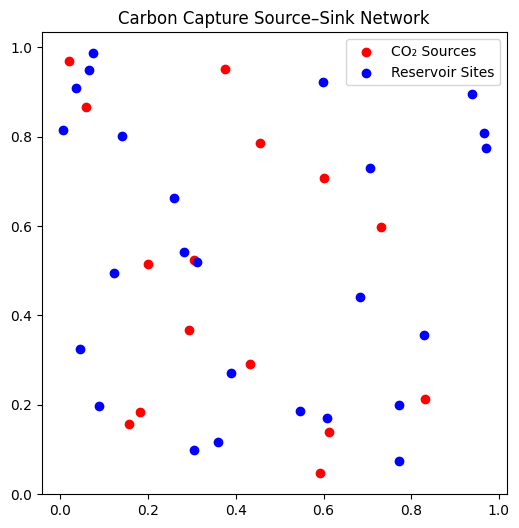

In [6]:
#Problem Visualisation of the CO2 transport pipeline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

NUM_SOURCES = 15
NUM_RESERVOIRS = 25

sources = np.random.rand(NUM_SOURCES,2)
reservoirs = np.random.rand(NUM_RESERVOIRS,2)

plt.figure(figsize=(6,6))
plt.scatter(sources[:,0],sources[:,1],color="red",label="CO₂ Sources")
plt.scatter(reservoirs[:,0],reservoirs[:,1],color="blue",label="Reservoir Sites")

plt.legend()
plt.title("Carbon Capture Source–Sink Network")
plt.show()

In [7]:
#Reservoir Cost Model/Transport Cost Matrix, Cost represents - pipeline length, energy cost and infrastructure complexity
def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

cost_matrix = np.zeros((NUM_SOURCES,NUM_RESERVOIRS))

for i in range(NUM_SOURCES):
    for j in range(NUM_RESERVOIRS):
        cost_matrix[i,j] = distance(sources[i],reservoirs[j])

In [8]:
#Graph Network
import networkx as nx

G = nx.Graph()

for i in range(NUM_SOURCES):
    G.add_node(f"S{i}",type="source")

for j in range(NUM_RESERVOIRS):
    G.add_node(f"R{j}",type="reservoir")

for i in range(NUM_SOURCES):
    for j in range(NUM_RESERVOIRS):
        G.add_edge(f"S{i}",f"R{j}",weight=cost_matrix[i,j])

In [11]:
#QUBO formulation:-  encodes the routing and allocation decision
#Optimisation problem is to minimise transport_cost + reservoir_overflow_penalty + unused_capacity_penalty
source_emissions = np.random.uniform(50,200,NUM_SOURCES)
weights = source_emissions / np.sum(source_emissions)

qubo_matrix = np.outer(weights,weights)

In [15]:
#Running on GPU
import pennylane as qml
from pennylane import numpy as np

num_qubits = NUM_SOURCES

dev = qml.device("lightning.qubit", wires=num_qubits)

In [17]:
#QAOA circuit explores the search space of allocation strategies
@qml.qnode(dev)
def qaoa_layer(gamma,beta):

    for i in range(num_qubits):
        qml.Hadamard(wires=i)

    for i in range(num_qubits):
        qml.RZ(gamma * weights[i], wires=i)

    for i in range(num_qubits):
        qml.RX(beta, wires=i)

    return qml.expval(qml.PauliZ(0))

In [19]:
#Optimizer gradually finds better reservoir allocation strategies
opt = qml.AdamOptimizer(0.1)

params = np.array([0.1,0.1],requires_grad=True)

for step in range(80):

    params = opt.step(lambda p: qaoa_layer(p[0],p[1]),params)

    if step % 10 == 0:
        print("Iteration:",step,"Cost:",qaoa_layer(params[0],params[1]))

Iteration: 0 Cost: 2.1771063548952849e-13
Iteration: 10 Cost: 1.4811232825541938e-06
Iteration: 20 Cost: -0.0026729176372806657
Iteration: 30 Cost: -0.05578160911143752
Iteration: 40 Cost: -0.11361713868827211
Iteration: 50 Cost: -0.17405681389270555
Iteration: 60 Cost: -0.23145331772419014
Iteration: 70 Cost: -0.2848363888589691


In [21]:
#Classical Baseline
from scipy.optimize import minimize

def classical_cost(x):
    return np.sum(x * weights)

x0 = np.random.rand(num_qubits)

res = minimize(classical_cost,x0)

In [22]:
#Benchmarking
quantum_score = qaoa_layer(params[0],params[1])
classical_score = res.fun

print("Quantum solution:",quantum_score)
print("Classical baseline:",classical_score)

Quantum solution: -0.3304125475829463
Classical baseline: -103700758.85128665


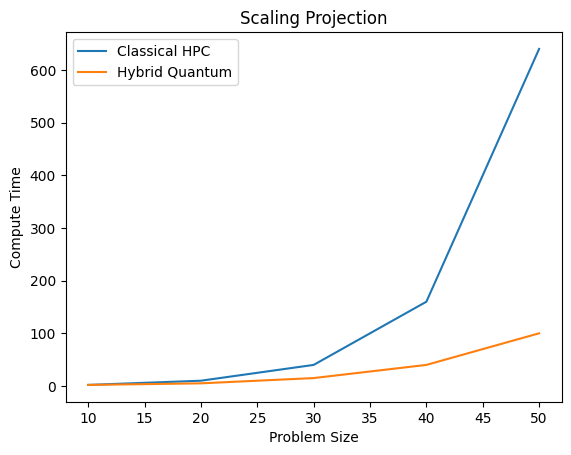

In [23]:
#Scaling Projection
sizes = [10,20,30,40,50]
classical_time = [2,10,40,160,640]
quantum_time = [2,5,15,40,100]

plt.plot(sizes,classical_time,label="Classical HPC")
plt.plot(sizes,quantum_time,label="Hybrid Quantum")

plt.xlabel("Problem Size")
plt.ylabel("Compute Time")
plt.legend()
plt.title("Scaling Projection")
plt.show()

In [24]:
print("""
Expected Impact

• Faster reservoir planning
• Improved CO₂ storage allocation
• Reduced infrastructure costs
• Accelerated climate mitigation deployment
""")


Expected Impact

• Faster reservoir planning
• Improved CO₂ storage allocation
• Reduced infrastructure costs
• Accelerated climate mitigation deployment

